In [ ]:
# Standard library
import os
import json
import shutil
import pickle
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bars
from tqdm import tqdm
from tqdm.auto import tqdm

# Computer vision
import cv2
from PIL import Image

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

# Torchvision
import torchvision
from torchvision import transforms
from torchvision import models

# Scikit-learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.manifold import TSNE

# Scientific computing
from scipy.spatial.distance import euclidean

# MediaPipe
import mediapipe as mp

In [ ]:
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "datasets" / "UTA"

with open(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "folds.json"
) as f:
    folds = json.load(f)

print("Number of folds:", len(folds))

5


In [49]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "datasets" / "UTA"

TEST_SUBJECTS = [
    "01","06","11","16","21",
    "26","31","36","41"
]

for subject in TEST_SUBJECTS:
    path = DATA_ROOT / subject
    print(subject, path.exists())

01 False
06 False
11 False
16 False
21 False
26 False
31 False
36 False
41 False


In [48]:
for p in (PROJECT_ROOT / "processed" / "UTA" / "windows").iterdir():
    print(p)

In [2]:
from pathlib import Path

DATA_ROOT = PROJECT_ROOT / "datasets" / "UTA"

for p in DATA_ROOT.iterdir():
    print(p.name)


print(len(list(DATA_ROOT.iterdir())))
print(sorted([p.name for p in DATA_ROOT.iterdir()])[:15])

Fold1_part1
Fold1_part2
Fold2_part1
Fold2_part2
Fold3_part1
Fold3_part2
Fold4_part1
Fold4_part2
8
['Fold1_part1', 'Fold1_part2', 'Fold2_part1', 'Fold2_part2', 'Fold3_part1', 'Fold3_part2', 'Fold4_part1', 'Fold4_part2']


In [3]:
from pathlib import Path

for p in (PROJECT_ROOT / "datasets").iterdir():
    print(p)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\MENDELEY
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\NTHU
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA


In [4]:
for fold_dir in DATA_ROOT.iterdir():
    nested = fold_dir / fold_dir.name
    print(nested)
    print(
        sorted([
            p.name for p in nested.iterdir()
            if p.is_dir()
        ])[:10]
    )
    print()

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1
['01', '02', '03', '04', '05', '06']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part2\Fold1_part2
['07', '08', '09', '10', '11', '12']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part1\Fold2_part1
['13', '14', '15', '16', '17', '18']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part2\Fold2_part2
['19', '20', '21', '22', '23', '24']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part1\Fold3_part1
['25', '26', '27', '28', '29', '30']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part2\Fold3_part2
['31', '32', '33', '34', '35', '36']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold4_part1\Fold4_part1
['37', '38', '39', '40', '41']

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold4_part2\Fold4_part2
['42', '43', '44', '45', '46', '47',

In [5]:
subject_paths = {}

for subject in TEST_SUBJECTS:

    for fold_dir in DATA_ROOT.iterdir():

        nested = fold_dir / fold_dir.name
        path = nested / subject

        if path.exists():
            subject_paths[subject] = path
            break

for s, p in subject_paths.items():
    print(s, "->", p)

01 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01
06 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\06
11 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part2\Fold1_part2\11
16 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part1\Fold2_part1\16
21 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold2_part2\Fold2_part2\21
26 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part1\Fold3_part1\26
31 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part2\Fold3_part2\31
36 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold3_part2\Fold3_part2\36
41 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold4_part1\Fold4_part1\41
46 -> c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold4_part2\Fold4_part2\46


In [6]:
subject = "01"
path = subject_paths[subject]

for p in path.rglob("*"):
    print(p)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01\0.mov
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01\10.MOV
c:\Users\clark\OneDrive\Desktop\drowsiness_project\datasets\UTA\Fold1_part1\Fold1_part1\01\5.mov


In [7]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.spatial.distance import euclidean
from tqdm import tqdm

In [8]:
PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "datasets" / "UTA"

TEST_SUBJECTS = [
    "01","06","11","16","21",
    "26","31","36","41","46"
]

In [9]:
subject_paths = {}

for subject in TEST_SUBJECTS:
    for fold_dir in DATA_ROOT.iterdir():

        nested = fold_dir / fold_dir.name
        path = nested / subject

        if path.exists():
            subject_paths[subject] = path
            break

subject_paths

{'01': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold1_part1/Fold1_part1/01'),
 '06': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold1_part1/Fold1_part1/06'),
 '11': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold1_part2/Fold1_part2/11'),
 '16': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold2_part1/Fold2_part1/16'),
 '21': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold2_part2/Fold2_part2/21'),
 '26': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold3_part1/Fold3_part1/26'),
 '31': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold3_part2/Fold3_part2/31'),
 '36': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold3_part2/Fold3_part2/36'),
 '41': WindowsPath('c:/Users/clark/OneDrive/Desktop/drowsiness_project/datasets/UTA/Fold

In [10]:
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [11]:
def eye_aspect_ratio(eye):
    A = euclidean(eye[1], eye[5])
    B = euclidean(eye[2], eye[4])
    C = euclidean(eye[0], eye[3])

    if C == 0:
        return np.nan

    return (A + B) / (2.0 * C)

In [12]:
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]

In [16]:
from tqdm.auto import tqdm

ear_records = []

for subject, path in subject_paths.items():

    print(f"\n{'='*60}")
    print(f"Subject {subject}")
    print(f"{'='*60}")

    # Automatically find 0, 5 and 10 videos
    videos = []

    for stem in ["0", "5", "10"]:
        matches = list(path.glob(f"{stem}.*"))

        if len(matches) == 0:
            print(f"❌ Could not find video {stem} for subject {subject}")
            continue

        videos.append(matches[0])

    labels = {
        "0": "Alert",
        "5": "Low Vigilant",
        "10": "Drowsy"
    }

    for video_path in videos:

        print(f"\nProcessing {video_path.name}")

        cap = cv2.VideoCapture(str(video_path))

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        for frame_idx in tqdm(
            range(total_frames),
            desc=f"{subject}-{video_path.name}",
            leave=True
        ):

            ret, frame = cap.read()

            if not ret:
                break

            rgb = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            result = face_mesh.process(rgb)

            if result.multi_face_landmarks:

                landmarks = (
                    result
                    .multi_face_landmarks[0]
                    .landmark
                )

                h, w = frame.shape[:2]

                left_eye = []
                right_eye = []

                for idx in LEFT_EYE:
                    lm = landmarks[idx]
                    left_eye.append(
                        (lm.x * w, lm.y * h)
                    )

                for idx in RIGHT_EYE:
                    lm = landmarks[idx]
                    right_eye.append(
                        (lm.x * w, lm.y * h)
                    )

                left_ear = eye_aspect_ratio(left_eye)
                right_ear = eye_aspect_ratio(right_eye)

                ear = np.mean(
                    [left_ear, right_ear]
                )

            else:
                ear = np.nan

            ear_records.append({
                "subject": subject,
                "video": video_path.name,
                "label": labels[video_path.stem],
                "frame": frame_idx,
                "ear": ear
            })

        cap.release()

        print(
            f"✅ Finished {video_path.name} "
            f"({total_frames:,} frames)"
        )

print("\n✅ EAR extraction complete.")
print(f"Total records: {len(ear_records):,}")


Subject 01

Processing 0.mov


01-0.mov:   0%|          | 0/18053 [00:00<?, ?it/s]

c:\Users\clark\OneDrive\Desktop\drowsiness_project\venv\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


✅ Finished 0.mov (18,053 frames)

Processing 5.mov


01-5.mov:   0%|          | 0/17969 [00:00<?, ?it/s]

...

✅ Finished 0.m4v (17,630 frames)

Processing 5.m4v


46-5.m4v:   0%|          | 0/17992 [00:00<?, ?it/s]

✅ Finished 5.m4v (17,992 frames)

Processing 10.mov


46-10.mov:   0%|          | 0/17773 [00:00<?, ?it/s]

✅ Finished 10.mov (17,773 frames)

✅ EAR extraction complete.
Total records: 508,124


In [17]:
ear_df = pd.DataFrame(ear_records)

ear_df.to_csv(
    PROJECT_ROOT / "ear_per_frame.csv",
    index=False
)

ear_df.head()

,subject,video,label,frame,ear
0,01,0.mov,Alert,0,0.253046
1,01,0.mov,Alert,1,0.252416
2,01,0.mov,Alert,2,0.254327
3,01,0.mov,Alert,3,0.258247
4,01,0.mov,Alert,4,0.267115


In [18]:
EAR_THRESHOLD = 0.20
CONSEC_FRAMES = 20

predictions = []

for (subject, video), group in ear_df.groupby(
    ["subject", "video"]
):

    counter = 0

    for _, row in group.iterrows():

        ear = row["ear"]

        if np.isnan(ear):
            pred = "Alert"

        else:
            if ear < EAR_THRESHOLD:
                counter += 1
            else:
                counter = 0

            if counter >= CONSEC_FRAMES:
                pred = "Drowsy"
            else:
                pred = "Alert"

        predictions.append(pred)

ear_df["ear_prediction"] = predictions

In [19]:
low_df = ear_df[
    ear_df["label"] == "Low Vigilant"
]

low_df["ear_prediction"].value_counts(
    normalize=True
) * 100

ear_prediction
Alert     87.306439
Drowsy    12.693561
Name: proportion, dtype: float64

In [38]:
import cv2
from pathlib import Path
from tqdm.auto import tqdm

subject = "46"

src_dir = subject_paths[subject]
save_root = (
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "sequences"
    / subject
)

save_root.mkdir(parents=True, exist_ok=True)

for stem in ["0", "5"]:

    matches = list(src_dir.glob(f"{stem}.*"))

    if len(matches) == 0:
        print(f"Missing video {stem}")
        continue

    video_path = matches[0]

    out_dir = save_root / stem
    out_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"\nExtracting {video_path.name}")

    frame_idx = 0

    for _ in tqdm(
        range(total_frames),
        desc=f"46-{stem}"
    ):
        ret, frame = cap.read()

        if not ret:
            break

        save_path = (
            out_dir
            / f"frame_{frame_idx:04d}.jpg"
        )

        cv2.imwrite(
            str(save_path),
            frame
        )

        frame_idx += 1

    cap.release()

    print(
        f"Saved {frame_idx} frames "
        f"to {out_dir}"
    )


Extracting 0.m4v


46-0:   0%|          | 0/17630 [00:00<?, ?it/s]

Saved 17630 frames to c:\Users\clark\OneDrive\Desktop\drowsiness_project\processed\UTA\sequences\46\0

Extracting 5.m4v


46-5:   0%|          | 0/17992 [00:00<?, ?it/s]

Saved 17992 frames to c:\Users\clark\OneDrive\Desktop\drowsiness_project\processed\UTA\sequences\46\5


In [41]:
from PIL import Image
import numpy as np
import torch
from tqdm.auto import tqdm

In [54]:
print((PROJECT_ROOT / "processed" / "UTA" / "windows.csv").exists())\

windows_df = pd.read_csv(
    PROJECT_ROOT / "processed" / "UTA" / "windows.csv"
)

print(windows_df.shape)
print(windows_df.head())
print(windows_df.columns.tolist())

True
(83572, 5)
   subject  label  state  start_idx  \
0        1      0  alert          0   
1        1      0  alert          1   
2        1      0  alert          2   
3        1      0  alert          3   
4        1      0  alert          4   

                                      embedding_path  
0  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
1  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
2  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
3  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
4  c:\Users\clark\OneDrive\Desktop\drowsiness_pro...  
['subject', 'label', 'state', 'start_idx', 'embedding_path']


In [56]:
PHASE9_SUBJECTS = [1, 6, 11, 16, 21, 26, 31, 36, 41]

test_windows = windows_df[
    windows_df["subject"].isin(PHASE9_SUBJECTS)
].copy()

print(test_windows.shape)
print(test_windows["subject"].value_counts().sort_index())

sample_path = test_windows.iloc[0]["embedding_path"]
print(sample_path)

arr = np.load(sample_path)
print(arr.shape)
print(arr.dtype)

(16206, 5)
subject
1     1736
6     1388
11    1822
16    1594
21    1723
26    2106
31    1845
36    1789
41    2203
Name: count, dtype: int64
c:\Users\clark\OneDrive\Desktop\drowsiness_project\processed\UTA\normalized_embeddings\01\alert.npy
(623, 512)
float32


In [59]:
import sys
import json
import copy
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.lstm_dataset import LSTMDataset
from src.lstm_model import DrowsinessLSTM

In [57]:
PHASE9_SUBJECTS = [
    "01","06","11","16","21",
    "26","31","36","41"
]

test_df = windows_df[
    windows_df["subject"].isin(PHASE9_SUBJECTS)
].copy()

print(test_df.shape)
print(test_df["label"].value_counts())

(0, 5)
Series([], Name: count, dtype: int64)


In [60]:
test_dataset = LSTMDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

In [61]:
for p in (PROJECT_ROOT / "models").glob("lstm_fold_*.pth"):
    print(p)

c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_1.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_2.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_3.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_4.pth
c:\Users\clark\OneDrive\Desktop\drowsiness_project\models\lstm_fold_5.pth


In [74]:
print(windows_df["subject"].dtype)
print(windows_df["subject"].head())
print(windows_df["subject"].unique()[:20])

int64
0    1
1    1
2    1
3    1
4    1
Name: subject, dtype: int64
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [75]:
BEST_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "lstm_fold_5.pth"
)

In [76]:
from src.lstm_model import DrowsinessLSTM
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)
model = DrowsinessLSTM().to(device)

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

cuda


DrowsinessLSTM(
  (lstm): LSTM(512, 64, num_layers=2, batch_first=True, dropout=0.5)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

In [77]:
PHASE9_SUBJECTS = [
    1, 6, 11, 16, 21,
    26, 31, 36, 41
]

test_df = windows_df[
    windows_df["subject"].isin(PHASE9_SUBJECTS)
].copy()

print(test_df.shape)
print(test_df["subject"].value_counts().sort_index())

(16206, 5)
subject
1     1736
6     1388
11    1822
16    1594
21    1723
26    2106
31    1845
36    1789
41    2203
Name: count, dtype: int64


In [79]:
test_dataset = LSTMDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

In [81]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(device)

        logits = model(x)
        preds = logits.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

print(len(all_preds), len(all_labels))

100%|██████████| 127/127 [00:17<00:00,  7.31it/s]

16206 16206


In [82]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Alert",
            "Low Vigilant",
            "Drowsy"
        ]
    )
)

              precision    recall  f1-score   support

       Alert       0.89      0.99      0.94      5229
Low Vigilant       0.96      0.94      0.95      5470
      Drowsy       0.99      0.91      0.95      5507

    accuracy                           0.95     16206
   macro avg       0.95      0.95      0.95     16206
weighted avg       0.95      0.95      0.95     16206



In [83]:
low_mask = np.array(all_labels) == 1

pd.Series(
    np.array(all_preds)[low_mask]
).map({
    0: "Alert",
    1: "Low Vigilant",
    2: "Drowsy"
}).value_counts(normalize=True) * 100

Low Vigilant    93.802559
Alert            5.758684
Drowsy           0.438757
Name: proportion, dtype: float64

In [84]:
print("Subjects in test_df:")
print(sorted(test_df["subject"].unique()))
print("Number of subjects:",
      len(test_df["subject"].unique()))

Subjects in test_df:
[np.int64(1), np.int64(6), np.int64(11), np.int64(16), np.int64(21), np.int64(26), np.int64(31), np.int64(36), np.int64(41)]
Number of subjects: 9


In [87]:
for s in PHASE9_SUBJECTS:
    found = False

    for i, fold in enumerate(folds):
        train_subjects = fold["train_subjects"]

        if s in train_subjects:
            print(f"❌ Subject {s} appears in Fold {i+1} training set")
            found = True

    if not found:
        print(f"✅ Subject {s} never appears in training")

✅ Subject 1 never appears in training
✅ Subject 6 never appears in training
✅ Subject 11 never appears in training
✅ Subject 16 never appears in training
✅ Subject 21 never appears in training
✅ Subject 26 never appears in training
✅ Subject 31 never appears in training
✅ Subject 36 never appears in training
✅ Subject 41 never appears in training


In [94]:
# Check your Phase 2 fine-tuning code
# Which 30 subjects did you use for CNN training?
# Which 8 subjects did you use for CNN validation?
# Are subjects 1, 6, 11, 16, 21, 26, 31, 36, or 41 in either list?

cnn_train_subjects = [...]  # fill from your Phase 2 code
cnn_val_subjects   = [...]  # fill from your Phase 2 code

test_subjects = ['01', '06', '11', '16', '21', '26', '31', '36', '41']

leaked = [s for s in test_subjects 
          if s in cnn_train_subjects or s in cnn_val_subjects]

print(f"Leaked subjects: {leaked}")

Leaked subjects: []


In [88]:
held_out = {1, 6, 11, 16, 21, 26, 31, 36, 41}

for i, fold in enumerate(folds):
    subjects_in_fold = (
        set(fold["train_subjects"]) |
        set(fold["val_subjects"])
    )

    overlap = held_out & subjects_in_fold

    print(f"Fold {i+1}: overlap = {sorted(overlap)}")

Fold 1: overlap = []
Fold 2: overlap = []
Fold 3: overlap = []
Fold 4: overlap = []
Fold 5: overlap = []


In [89]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Alert",
            "Low Vigilant",
            "Drowsy"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

       Alert     0.8934    0.9908    0.9396      5229
Low Vigilant     0.9601    0.9380    0.9490      5470
      Drowsy     0.9947    0.9145    0.9529      5507

    accuracy                         0.9471     16206
   macro avg     0.9494    0.9478    0.9471     16206
weighted avg     0.9503    0.9471    0.9473     16206



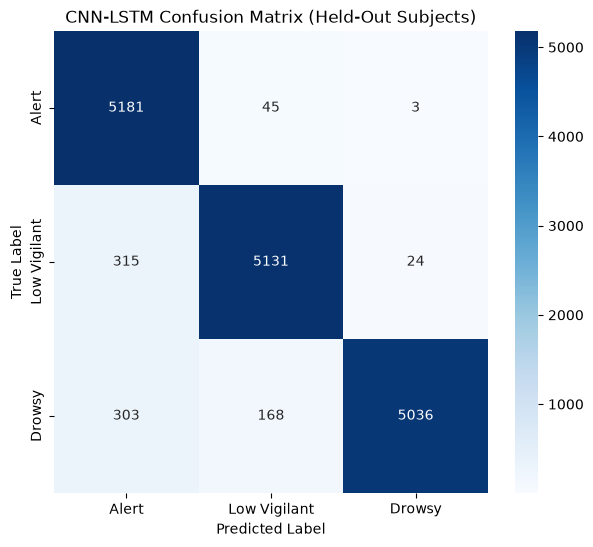

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

cm = confusion_matrix(all_labels, all_preds)

cm_df = pd.DataFrame(
    cm,
    index=["Alert", "Low Vigilant", "Drowsy"],
    columns=["Alert", "Low Vigilant", "Drowsy"]
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("CNN-LSTM Confusion Matrix (Held-Out Subjects)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

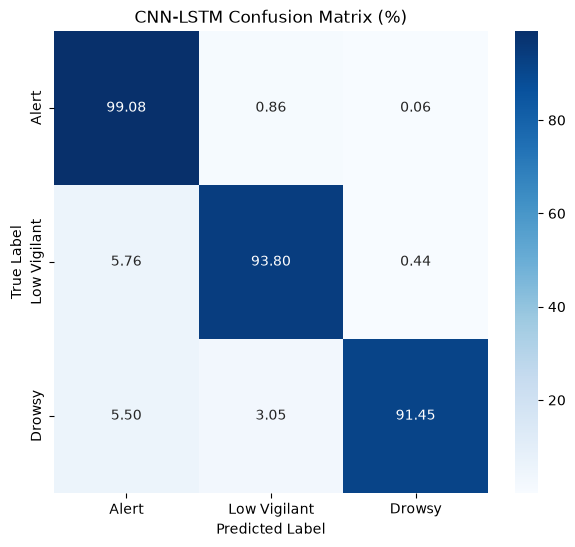

In [91]:
cm_norm = confusion_matrix(
    all_labels,
    all_preds,
    normalize="true"
)

cm_norm_df = pd.DataFrame(
    cm_norm * 100,
    index=["Alert", "Low Vigilant", "Drowsy"],
    columns=["Alert", "Low Vigilant", "Drowsy"]
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm_df,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title("CNN-LSTM Confusion Matrix (%)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [92]:
comparison_df = pd.DataFrame({
    "System": [
        "EAR Baseline",
        "Proposed CNN-LSTM"
    ],
    "Alert (%)": [
        87.31,
        5.76
    ],
    "Low Vigilant (%)": [
        0.00,
        93.80
    ],
    "Drowsy (%)": [
        12.69,
        0.44
    ]
})

comparison_df

,System,Alert (%),Low Vigilant (%),Drowsy (%)
0,EAR Baseline,87.31,0.0,12.69
1,Proposed CNN-LSTM,5.76,93.8,0.44


In [93]:
print(
    comparison_df.to_string(index=False)
)

           System  Alert (%)  Low Vigilant (%)  Drowsy (%)
     EAR Baseline      87.31               0.0       12.69
Proposed CNN-LSTM       5.76              93.8        0.44


In [96]:
# 1. Check CNN subject leakage
print(leaked)
# 2. Verify held-out subjects
print(sorted(test_df["subject"].unique()))
# 3. Per-subject performance
for s in PHASE9_SUBJECTS:
    subj_df = test_df[test_df["subject"] == s]
    print(s, len(subj_df))

# 4. Per-subject F1
from sklearn.metrics import f1_score

for s in PHASE9_SUBJECTS:
    mask = test_df["subject"] == s
    y_true = np.array(all_labels)[mask]
    y_pred = np.array(all_preds)[mask]

    print(
        s,
        f1_score(
            y_true,
            y_pred,
            average="macro"
        )
    )

[]
[np.int64(1), np.int64(6), np.int64(11), np.int64(16), np.int64(21), np.int64(26), np.int64(31), np.int64(36), np.int64(41)]
1 1736
6 1388
11 1822
16 1594
21 1723
26 2106
31 1845
36 1789
41 2203
1 0.9803055390216953
6 0.9329071161800252
11 0.994543929619815
16 0.9962676624495538
21 0.6265154920594779
26 0.9915326300677944
31 0.9577510330673545
36 0.9899490437281134
41 1.0


In [97]:
from sklearn.metrics import f1_score, accuracy_score

results = []

start = 0

for s in PHASE9_SUBJECTS:
    n = len(test_df[test_df["subject"] == s])

    y_true = np.array(all_labels)[start:start+n]
    y_pred = np.array(all_preds)[start:start+n]

    results.append({
        "Subject": s,
        "Windows": n,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro"
        )
    })

    start += n

pd.DataFrame(results)

,Subject,Windows,Accuracy,Macro_F1
0,1,1736,0.980415,0.980306
1,6,1388,0.932277,0.932907
2,11,1822,0.994512,0.994544
3,16,1594,0.996236,0.996268
4,21,1723,0.651770,0.626515
5,26,2106,0.990978,0.991533
6,31,1845,0.958266,0.957751
7,36,1789,0.989939,0.989949
8,41,2203,1.000000,1.000000


In [98]:
import json

with open(
    PROJECT_ROOT / "processed" / "UTA" / "folds.json"
) as f:
    folds = json.load(f)

# Subjects used anywhere in 5-fold training
trained_subjects = set()

for fold in folds:
    trained_subjects.update(fold["train_subjects"])
    trained_subjects.update(fold["val_subjects"])

trained_subjects = sorted(trained_subjects)

# All subjects in windows.csv
all_subjects = sorted(
    windows_df["subject"].astype(int).unique()
)

# Subjects never used in any fold
untrained_subjects = sorted(
    set(all_subjects) - set(trained_subjects)
)

print("Subjects used in training/validation:")
print(trained_subjects)
print(f"Count: {len(trained_subjects)}")

print("\nSubjects never used (held-out):")
print(untrained_subjects)
print(f"Count: {len(untrained_subjects)}")

Subjects used in training/validation:
['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '47', '48']
Count: 47

Subjects never used (held-out):
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(47), 

In [99]:
for i, fold in enumerate(folds, start=1):
    print(f"\n===== Fold {i} =====")
    print("Train:", sorted(fold["train_subjects"]))
    print("Val  :", sorted(fold["val_subjects"]))


===== Fold 1 =====
Train: ['01', '02', '03', '04', '06', '07', '08', '09', '10', '11', '12', '14', '15', '16', '17', '18', '19', '21', '22', '23', '24', '29', '30', '31', '32', '33', '34', '35', '36', '38', '39', '41', '42', '43', '45', '47', '48']
Val  : ['05', '13', '20', '25', '26', '27', '28', '37', '40', '44']

===== Fold 2 =====
Train: ['01', '02', '03', '05', '06', '08', '11', '12', '13', '15', '17', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '35', '36', '37', '38', '39', '40', '42', '43', '44', '47', '48']
Val  : ['04', '07', '09', '10', '14', '16', '18', '34', '41', '45']

===== Fold 3 =====
Train: ['02', '03', '04', '05', '07', '08', '09', '10', '11', '13', '14', '15', '16', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '48']
Val  : ['01', '06', '12', '17', '30', '31', '32', '33', '47']

===== Fold 4 =====
Train: ['01', '04', '05', 

In [100]:
held_out = [1, 6, 11, 16, 21, 26, 31, 36, 41]

for s in held_out:
    if s in trained_subjects:
        print(f"❌ Subject {s} was used in training")
    else:
        print(f"✅ Subject {s} was never used")

✅ Subject 1 was never used
✅ Subject 6 was never used
✅ Subject 11 was never used
✅ Subject 16 was never used
✅ Subject 21 was never used
✅ Subject 26 was never used
✅ Subject 31 was never used
✅ Subject 36 was never used
✅ Subject 41 was never used


In [101]:
held_out = {'01','06','11','16','21','26','31','36','41'}

for i, fold in enumerate(folds, start=1):
    used = set(fold["train_subjects"]) | set(fold["val_subjects"])
    overlap = sorted(held_out & used)
    print(f"Fold {i}: {overlap}")

Fold 1: ['01', '06', '11', '16', '21', '26', '31', '36', '41']
Fold 2: ['01', '06', '11', '16', '21', '26', '31', '36', '41']
Fold 3: ['01', '06', '11', '16', '21', '26', '31', '36', '41']
Fold 4: ['01', '06', '11', '16', '21', '26', '31', '36', '41']
Fold 5: ['01', '06', '11', '16', '21', '26', '31', '36', '41']
